**Gerenciamento da Classe Livro**

In [72]:
#Iniciando a classe Livro
class Livro:

    #A variável livros recebe uma lista vazia na qual armazenará os livros cadastrados
    #A lista é um atributo da classe
    livros = []

    #O construtor tem todos os atributos de um livro
    #O self permite que os atributos sejam lidos por toda a classe
    def __init__ (self, titulo, autor, genero, qtd_disponivel):
        self.titulo = titulo
        self.autor = autor
        self.genero = genero
        self.qtd_disponivel = qtd_disponivel

    #Utilizando o classmethod eu defino minha função como um método da classe
    #Isso me permite chamar essa função sem a necessidade de instanciar a classe, como ocorreria se fosse usado o self.
    #Com isso, onde ficaria o self é substituido por cls

    @classmethod
    def listar_livros(cls):

      #Primeiro crio a variável resultado que recebe um valor vazio
      resultado = ""

      #A estrutura de repetição lista todos os livros da lista
      for livro in cls.livros:
          #A variável resultado agora vai concatenar o resultado da lista
          #Isso faz com que todo livro cadastrado seja acrescentado na lista, e não substituido
          resultado += (f"Titulo: {livro.titulo}\nAutor: {livro.autor}\nGênero: {livro.genero},\nQuantidade Disponível: {livro.qtd_disponivel}\n\n")
      return resultado

    #A função recebe os atributos que vão ser cadastrados por meio do parâmetro self
    #Como a lista é um atributo da classe, então é chamada por meio da classe Livro
    #Após a chamda da lista é atribuido a função built-in .append() para inserir o cadastro na lista vazia
    #O self é a instância da classe livro, por isso, ao usar ela dentro do .append() eu informo que toda a instância livro vai ser cadastrada

    def cadastrar_livro(self):
        Livro.livros.append(self)

    #A Função buscar_livro também é um método da classe
    #Ultilizo o atributo titulo para definir a lógica no if
    @classmethod
    def buscar_livro(cls, titulo):
        #A estrutura de repetição lista todos os livros da lista
        for livro in Livro.livros:
            #Aplico a condição de se o titulo buscado for igual ao titulo existente ele retorna o livro da lista
            if livro.titulo == titulo:
                return livro
        return None

**Cadastro de um novo livro**



In [74]:
#cadastrar livro
#Cada input recebe o valor de um atributo do livro
#Esses valores são armazenados em sua respectiva variável e passada na chamada da classe Livro
#A classe acessa a função cadastrar_livro para execultar a função com os valores passados

valor_titulo = input("Qual o titulo do livro?")
valor_autor = input("Qual o autor do livro? ")
valor_genero = input("Qual o genêro do livro?")
valor_qtd_disponivel = input("Quantas unidades estão disponiveis?")

Livro(valor_titulo, valor_autor, valor_genero, valor_qtd_disponivel).cadastrar_livro()

Qual o titulo do livro?É assim que acaba
Qual o autor do livro? Colleen Hoover
Qual o genêro do livro?Romance
Quantas unidades estão disponiveis?7


**Visualização dos livros cadastrados**

In [75]:
#Visualizar os livros cadastrados
#Por ser um método da classe eu apenas escrevo a classe e buscar a função que no caso é listar livros()
#Sem a necessidade de instanciar a classe

print(Livro.listar_livros())

Titulo: IT a coisa
Autor: Stephen King
Gênero: Terror,
Quantidade Disponível: 4

Titulo: É assim que acaba
Autor: Colleen Hoover
Gênero: Romance,
Quantidade Disponível: 7




**Busca dos livros por titulo**

In [80]:
#Buscar livro
#O valor da pesquisa passado no input é armazenado na variável valor_pesquisar
#A variável livro_encontado utiliza esse valor na função buscar_livro

valor_pesquisar = input("Qual o titulo do livro que deseja buscar?")
livro_encontrado = Livro.buscar_livro(valor_pesquisar)

#Com o valor na variável eu aplico a lógica na condicional de se o livro existir na lista eu retorno as informações dele
#Caso contrário eu retorno que o livro não foi encontrado

if livro_encontrado:
    print(f"\n Livro encontrado: {livro_encontrado.titulo} \n Autor: {livro_encontrado.autor} \n Quantidade disponivel: {livro_encontrado.qtd_disponivel}")
else:
    print("Livro não encontrado.")

Qual o titulo do livro que deseja buscar?IT a coisa

 Livro encontrado: IT a coisa 
 Autor: Stephen King 
 Quantidade disponivel: 4


**Gráfico de quantidade de livros por gênero**

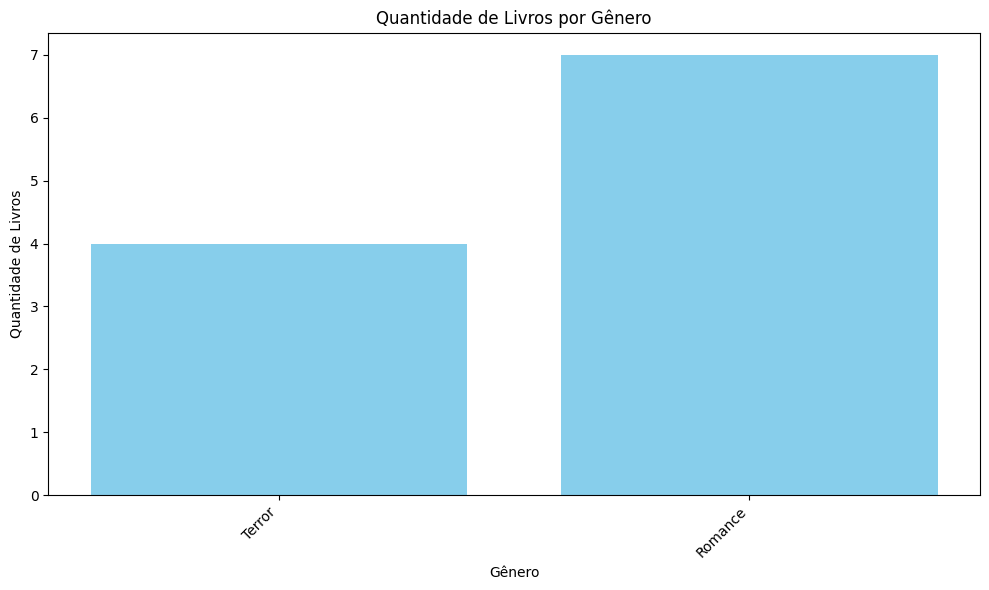

In [78]:
import matplotlib.pyplot as plt
import pandas as pd

# Inicializa um dicionário vazio para armazenar a contagem de livros por gênero.
genre_counts = {}

# Itera sobre a lista de livros (Livro.livros) para coletar os dados de gênero e quantidade.
for livro in Livro.livros:
    genre = livro.genero
    # Tenta converter a quantidade disponível para um número inteiro.
    # Se houver erro na conversão (por exemplo, se não for um número), a quantidade é definida como 0.
    try:
        quantity = int(livro.qtd_disponivel)
    except ValueError:
        quantity = 0 # Define como 0 se a conversão falhar

    # Se o gênero já existe no dicionário, adiciona a quantidade atual.
    # Caso contrário, inicializa a contagem para o novo gênero.
    if genre in genre_counts:
        genre_counts[genre] += quantity
    else:
        genre_counts[genre] = quantity

# Extrai os gêneros (chaves do dicionário) e as quantidades (valores do dicionário) em listas separadas.
genres = list(genre_counts.keys())
quantities = list(genre_counts.values())

# Cria a figura e os eixos do gráfico com um tamanho específico.
plt.figure(figsize=(10, 6))
# Gera um gráfico de barras, onde 'genres' são as categorias e 'quantities' são as alturas das barras.
plt.bar(genres, quantities, color='skyblue')

# Adiciona rótulos aos eixos e um título ao gráfico para melhor compreensão.
plt.xlabel('Gênero')
plt.ylabel('Quantidade de Livros')
plt.title('Quantidade de Livros por Gênero')
# Rotaciona os rótulos do eixo X em 45 graus e alinha à direita para evitar sobreposição.
plt.xticks(rotation=45, ha='right')
# Ajusta automaticamente os parâmetros da figura para que não haja sobreposição de elementos.
plt.tight_layout()

# Exibe o gráfico gerado.
plt.show()